In [1]:
import numpy as np
import solve_Cosmo as NSC

import tqdm as tqdm 

import matplotlib.pyplot as plt

In [2]:
a1 = NSC.Track_all_lam(1e12, d_decay=6, lam=1e16 )

final temp 5.217e+03



In [3]:
rhor1, rhoQ1, srad1, Temp1, lu , sV, rhoQ_af1, rhor_af1, ulfin = a1

Text(0.5, 0, '$1/T\\,\\,\\left[{\\rm GeV}^{-1}\\right]$')

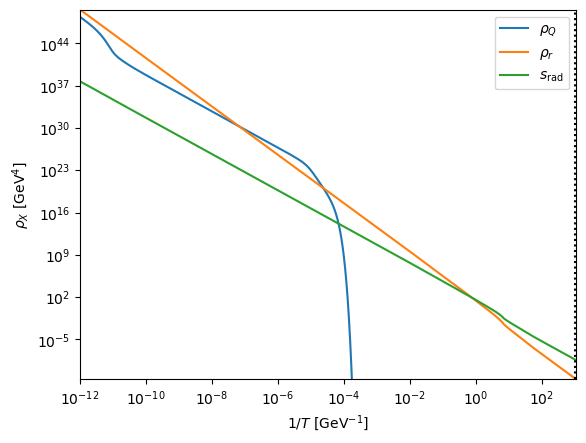

In [4]:
plt.loglog(1/Temp1,  rhoQ1, label=r'$\rho_Q$')

plt.loglog(1/Temp1, rhor1, label=r'$\rho_r$')

plt.loglog(1/Temp1, srad1, label=r'$s_{\rm rad}$')

plt.axvline(1/1e-3, ls=':', color='k')

plt.ylim(np.min(rhor1), np.max(rhor1))
plt.xlim(1/Temp1[0], 1/Temp1[-1])

plt.legend()
plt.ylabel(r'$\rho_X\,\,\left[{\rm GeV}^{4}\right]$')
plt.xlabel(r'$1/T\,\,\left[{\rm GeV}^{-1}\right]$')

- Can track the total entropy difference $s_{\rm rad}a^3$ where $a$ is the scale factor. 

- Below I only have the plot for the period of decay, due to the way the solver works. 

Text(0.5, 0, '$\\log(a/a_i)$')

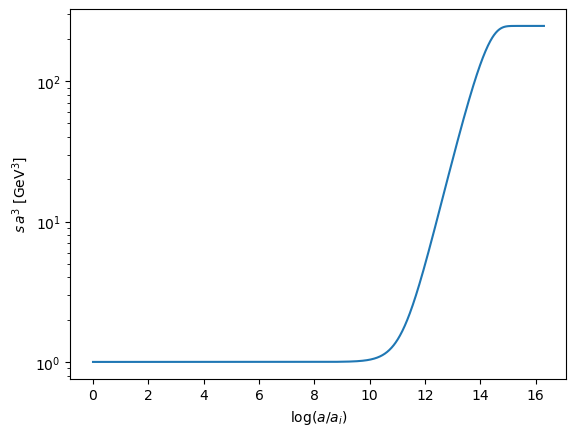

In [5]:
plt.semilogy(lu, sV/sV[0])


plt.ylabel(r'$s\, a^3\,\,\left[{\rm GeV}^3\right]$')



plt.xlabel(r'$\log(a/a_i)$')

- I also have the densities in this region so check their behaviour

Text(0.5, 0, '$\\log(a/a_i)$')

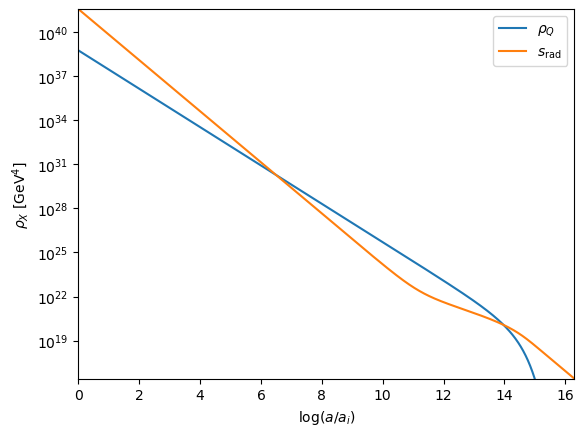

In [6]:
plt.semilogy(lu, rhoQ_af1, label=r'$\rho_Q$')
plt.semilogy(lu, rhor_af1, label=r'$s_{\rm rad}$')


plt.ylim(np.min(rhor_af1), np.max(rhor_af1))
plt.xlim(lu[0], lu[-1])

plt.legend()
plt.ylabel(r'$\rho_X\,\,\left[{\rm GeV}^{4}\right]$')
plt.xlabel(r'$\log(a/a_i)$')

- For creating the GW spectrum we don't need all this information, we just call the following. 

In [7]:
?NSC.GW_input_lam

Signature: NSC.GW_input_lam(mQ_p, d_decay=6, lam=1.22e+19, ratio_Ti=1.0)
Docstring: return sRad_volume_aFO[-1]/sRad_volume_aFO[0] , Teq, Tdec
File:      ~/Documents/Tools/NSC/NSC/solve_Cosmo.py
Type:      function

In [41]:
invdil, Teq, Tdec = NSC.GW_input_lam(1e9, 6, 1e16)

print(invdil, Teq, Tdec)

8429.988973812675 29.76450614432698 0.002410749348427182


- I think you have enough information to create the GW signal here, but I will show an example here.  

In [42]:
import GW_spectrum as GW

In [43]:
a0=1 
h= 0.7 
Hub0 = h * (9.777)**(-1) * 3.168e-17
TRH = 1e16
nT = 0.5 


fspace = np.logspace(-10, 10, 100)
k_values = 2*np.pi*fspace

In [44]:
GW_results = []
if Teq == 0:
    # If Teq == 0, return the result of OmegaGW the Standard cosmology for all k values
    for k in k_values:
        GW_results.append(GW.OmegaGW(k, TRH, nT, h=h))
else:
    # Compute OmegaGW for each k with an intermediate matter domination
    for k in k_values:
        result = (
            (1/12) * (k / (a0 * Hub0))**2
            * GW.T2TIMD_dil(k, Tdec, Teq, TRH, invdil)
            * GW.PT_func(k, nT)
        )
        GW_results.append(result)



Text(0.5, 0, '$f\\,\\left[{\\rm Hz}\\right]$')

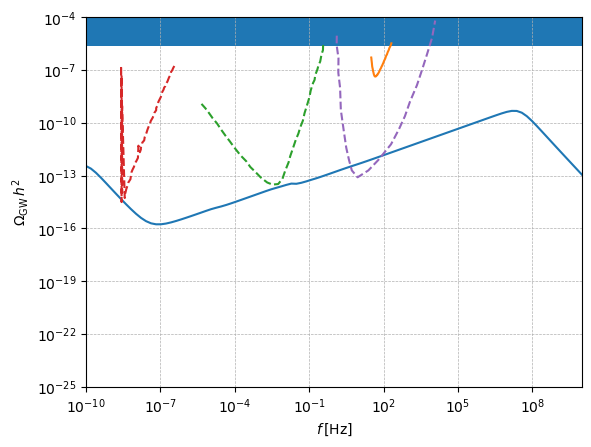

In [45]:
fig, ax =  plt.subplots()


plt.loglog(fspace, GW_results)


plt.loglog(10**GW.LIGOf, 10**GW.LIGO_OmGW)

plt.loglog(10**GW.LISAf, 10**GW.LISA_OmGW, ls='--')
plt.loglog(10**GW.SKA20f, 10**GW.SKA20_om, ls='--')
plt.loglog(GW.ETf, GW.ET_om, ls='--')

plt.axhspan(0.4*5.6e-6, 1)


plt.xlim(xmin=1e-10, xmax=1e10)
plt.ylim(1e-25, 1e-4)
ax.grid(which='both', linestyle='--', linewidth=0.5)

plt.ylabel(r'$\Omega_{\rm GW}\, h^2$')
plt.xlabel(r'$f\,\left[{\rm Hz}\right]$')

- Can do a scan of $\Lambda$ and $m_Q$ to find the GW overproduction 

In [13]:
lam1D = np.geomspace(1e12, 5e19, 100)
mQ1D = np.geomspace(1e10, 1e16, 100)

MQ2D, LAM2D = np.meshgrid(mQ1D, lam1D)

In [14]:
tqdm

<module 'tqdm' from '/home/andrew/anaconda3/lib/python3.11/site-packages/tqdm/__init__.py'>

In [15]:

omGWmax_d6 = np.zeros(np.shape(MQ2D))

for i in tqdm.tqdm(range(len(MQ2D[:,0]))):
    for j in range(len(MQ2D[0,:])):
        tmp_mQ = MQ2D[i,j]
        tmp_Lam = LAM2D[i,j]
        tmp_GW = GW.OmegaGW_preferred_axion_lam(2*np.pi*fspace, tmp_mQ, 
                                                TRH, nT, 6, tmp_Lam)
        omGWmax_d6[i,j] = np.max(tmp_GW)

100%|██████████| 100/100 [18:04:58<00:00, 650.98s/it]   


In [16]:
omGWmax_d6

array([[3.77008106e-04, 3.77008106e-04, 3.77008106e-04, ...,
        3.62902868e-04, 3.61800719e-04, 3.21603825e-04],
       [3.77008106e-04, 3.77008106e-04, 3.77008106e-04, ...,
        3.62902868e-04, 3.61800719e-04, 3.21603825e-04],
       [3.77008106e-04, 3.77008106e-04, 3.77008106e-04, ...,
        3.62902868e-04, 3.61800719e-04, 3.21603825e-04],
       ...,
       [1.26078683e-19, 1.42588008e-19, 1.61196680e-19, ...,
        1.67101999e-08, 2.00030267e-08, 2.40251422e-08],
       [7.29495435e-20, 8.27489065e-20, 9.38213581e-20, ...,
        1.42573805e-08, 1.66455454e-08, 1.99386423e-08],
       [4.24506513e-20, 4.77856159e-20, 5.38840264e-20, ...,
        1.20142103e-08, 1.41308176e-08, 1.65313230e-08]])

Text(0, 0.5, '$\\Lambda\\,\\,\\left[{\\rm GeV}\\right]$')

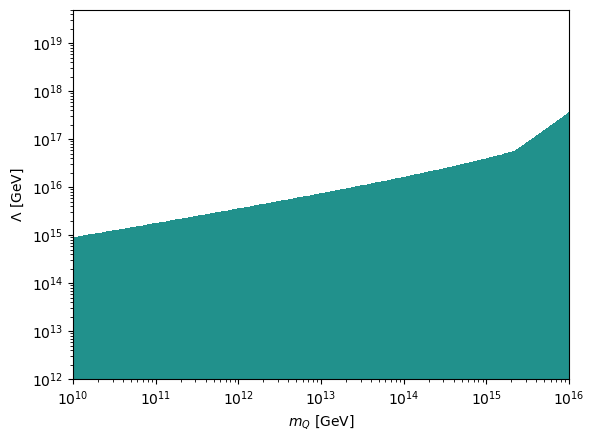

In [47]:
plt.yscale("log")
plt.xscale("log")

plt.contourf(MQ2D, LAM2D, omGWmax_d6, levels=[0.4*5.6e-6, 100])
plt.xlabel(r'$m_Q\,\,\left[{\rm GeV}\right]$')
plt.ylabel(r'$\Lambda\,\,\left[{\rm GeV}\right]$')

In [19]:
np.save('omGWmaxd6.npy', [MQ2D, LAM2D, omGWmax_d6], allow_pickle=True)